# CONTEXTUALIZACION
Practica para programacion de Ciencia de Datos II

Miller Andres Abril Nuñez

Introduccion
Los datos son probablemente los activos más valiosos en la actualidad. 
Su análisis es fundamental para obtener información relevante y tomar decisiones informadas. 
Sin embargo, trabajar con grandes cantidades de datos puede resultar abrumador si no se utiliza una herramienta adecuada como el DataFrame. (Fernández, 2023).

*Primera instancia: Importacion de Librerias correspondientes __preparacion del Entorno y carga de Datos.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, chi2_contingency

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score, accuracy_score,
                             confusion_matrix, classification_report,
                             recall_score, roc_auc_score, roc_curve)

#Se usan **pandas** y **numpy** para manipulación; **seaborn/matplotlib** para visualización; **scipy.stats** para inferencia; y **scikit-learn** para los modelos predictivos.'''
print("Bibliotecas cargadas")


Bibliotecas cargadas


In [2]:
#Carga de datos desde la API_ fase de exploracion

url_csv = "https://raw.githubusercontent.com/Miller1993Abril/Cr-menes-en-Colombia/main/datos_col.csv"
df = pd.read_csv(url_csv)
print("datos cargados correctamente desde la API Integrado con GitHub")
print("==============================================================")

print("Nombre columnas del Dataset")
print("===========================")
display(df.columns.tolist())# Devuelve las columnas del Dataset
print("=====================================================================================================================")
display (df.head(3)) # Devuelve el encabezado (numero de filas a ver)
print("=====================================================================================================================")
print(f'Dimensiones: {df.shape[0]} filas x {df.shape[1]} columnas') #Dimensiones
print("======================================")
df.info() # revision General del tipo de dato de los pandas,Numero de columna,columna, filas Nulas,Tipo de Dato, Resumen tipo de Dato memoria Usada.
print("======================================")

datos cargados correctamente desde la API Integrado con GitHub
Nombre columnas del Dataset


['departamento',
 'municipio',
 'codigo',
 'arma',
 'fecha',
 'genero',
 'edad_grupo',
 'cantidad']

,departamento,municipio,codigo,arma,fecha,genero,edad_grupo,cantidad
0,ANTIOQUIA,AMAGÁ,5030000,ARMA BLANCA / CORTOPUNZANTE,01/01/2010,MASCULINO,ADULTOS,1
1,ANTIOQUIA,MEDELLÍN (CT),5001000,ARMA BLANCA / CORTOPUNZANTE,01/01/2010,MASCULINO,ADULTOS,1
2,ANTIOQUIA,RIONEGRO,5615000,ARMA BLANCA / CORTOPUNZANTE,01/01/2010,MASCULINO,ADULTOS,1


Dimensiones: 130024 filas x 8 columnas
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130024 entries, 0 to 130023
Data columns (total 8 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   departamento  130024 non-null  object
 1   municipio     130024 non-null  object
 2   codigo        130024 non-null  int64 
 3   arma          130024 non-null  object
 4   fecha         130024 non-null  object
 5   genero        130024 non-null  object
 6   edad_grupo    130024 non-null  object
 7   cantidad      130024 non-null  int64 
dtypes: int64(2), object(6)
memory usage: 7.9+ MB


In [3]:
# Verificacion de campos nulos o faltantes y conteo de datos Unicos en cada columna del dataFrame.
# Identificacion de la Poblacion si hablamos de caracterizacion sectorial.
diccionario = pd.DataFrame({
    'variable': df.columns,
    'tipo': [str(t) for t in df.dtypes],
    'faltantes': df.isna().sum().values,
    'unicos': df.nunique().values
})
diccionario 

,variable,tipo,faltantes,unicos
0,departamento,object,0,32
1,municipio,object,0,1001
2,codigo,int64,0,1077
3,arma,object,0,37
4,fecha,object,0,4230
5,genero,object,0,3
6,edad_grupo,object,0,4
7,cantidad,int64,0,16


In [4]:
df.isnull().sum() #Verificacion de campos vacios, funcion para el conteno de datos Nulos.

departamento    0
municipio       0
codigo          0
arma            0
fecha           0
genero          0
edad_grupo      0
cantidad        0
dtype: int64

In [5]:
#revision de los grupos poblacionales
print("==============================")
print("\n".join(df['genero'].unique()))    
print("==============================")
print("\n".join(df['edad_grupo'].unique())) 
print("==============================")

MASCULINO
FEMENINO
NO REPORTA
ADULTOS
ADOLESCENTES
MENORES
 


El actual dataset muestra 1001 Municipios a nivel Nacional en 130024 registros, son dos generos pero hay informacion Nula que se cambia por No registra para tener en cuenta la variable de esa linea de registro y sus demas datos para indicadores.

Se observa en el caso edad_grupo  3 datos unicos, ADULTOS,ADOLESCENTES,MENORES, en el conteo de valores se verifican 4, indica que hay un atributo ESPACIO EN BLANCO, ya que previamente no se identificaron datos Nulos, Se modifica el dato en BLANCO a (NO REGISTRA)y hacer uso de los datos de la fila para sumar Indicadores.

In [6]:
df['edad_grupo'] = df['edad_grupo'].replace(['', ' '], 'NO REGISTRA').str.strip() # Cambio vavios o espacios [] por No registra

In [7]:
print("\n".join(df['edad_grupo'].unique())) # Verificacion de los atributos modificados mediante la visualizacion de la variable edad_grupo.

ADULTOS
ADOLESCENTES
MENORES
NO REGISTRA


In [8]:
#Mediciones Estadisticas

columna_categoria = 'arma'

# Cantidad de registros por categoría
valores_categoria = df[columna_categoria].value_counts()

# Total de registros
total_registros = len(df)

# Porcentaje por categoría
porcentajes = (valores_categoria / total_registros) * 100

# Crear DataFrame resumen
resumen = pd.DataFrame({
    'Registros': valores_categoria,
    'Porcentaje': porcentajes.round(4)
})

print(f"_________ Porcentaje por {columna_categoria} _________")
print(f"Cantidad de categorías: {df[columna_categoria].nunique()}")
print(f"Total de registros: {total_registros}\n")

print(resumen)



_________ Porcentaje por arma _________
Cantidad de categorías: 37
Total de registros: 130024

                                    Registros  Porcentaje
arma                                                     
ARMA DE FUEGO                           94993     73.0581
ARMA BLANCA / CORTOPUNZANTE             27663     21.2753
CONTUNDENTES                             5134      3.9485
CUERDA/SOGA/CADENA                        413      0.3176
ARTEFACTO EXPLOSIVO/CARGA DINAMITA        389      0.2992
MINA ANTIPERSONA                          276      0.2123
NO REPORTADO                              219      0.1684
BOLSA PLASTICA                            167      0.1284
PUNZANTES                                 151      0.1161
GRANADA DE MANO                           115      0.0884
CORTANTES                                 111      0.0854
COMBUSTIBLE                                74      0.0569
SIN EMPLEO DE ARMAS                        62      0.0477
CINTAS/CINTURON                    

In [9]:
# Media. Casos mas representativo por departamento

# Total de casos en general por departamento
total_todos = df.groupby('departamento')['cantidad'].sum()

# Filtrar solo los casos con ARMA DE FUEGO
solo_fuego = df[df['arma'] == 'ARMA DE FUEGO']

# Solo los casos que SÍ fueron con arma de fuego
total_fuego = solo_fuego.groupby('departamento')['cantidad'].sum()

# crear la tabla del dataFrame
resumen = pd.DataFrame({
    'Total_General': total_todos,
    'Total_Arma_Fuego': total_fuego
})

# Reemplazar por 0 si no hay casos para que se tenga en cuenta todos los departamentos
resumen = resumen.fillna(0)

# Porcentaje de cada departamento con el arma filtrada en el dataFrame
resumen['Porcentaje_Arma_Fuego'] = (resumen['Total_Arma_Fuego'] / resumen['Total_General']) * 100

resumen['Porcentaje_Arma_Fuego'] = resumen['Porcentaje_Arma_Fuego'].round(2).astype(str) + ' %'

# Ordenar de mayor a menor la variable Total General para ver los departamentos mas afectados
resumen = resumen.sort_values('Total_General', ascending=False)
print(resumen.round(2))
media_porcentaje = resumen['Porcentaje_Arma_Fuego'].str.replace(' %','').astype(float).mean()
print(f"\nPromedio general de uso de Arma de Fuego: {media_porcentaje:.2f} %")


                    Total_General  Total_Arma_Fuego Porcentaje_Arma_Fuego
departamento                                                             
VALLE                       31772             26853               84.52 %
ANTIOQUIA                   27059             21038               77.75 %
CUNDINAMARCA                19182             11288               58.85 %
CAUCA                        7259              5768               79.46 %
NARIÑO                       6501              4861               74.77 %
ATLÁNTICO                    6316              4924               77.96 %
NORTE DE SANTANDER           5913              4896                82.8 %
BOLÍVAR                      4514              3158               69.96 %
CÓRDOBA                      4282              3737               87.27 %
TOLIMA                       3721              2463               66.19 %
META                         3645              2707               74.27 %
RISARALDA                    3575     

Con el previo analisis se puede determinar el total de casos, cuantos usaron Arma de Fuego como variable mas grande, porcentaje de presencialidad en cada departamento y el promedio de uso del tipo de arma.

In [10]:
# Niveles de significancia mas alta
resumen = resumen.sort_values('Total_General', ascending=False)
print(resumen.round(2).head(5))
print("=======================================================================")
print(f"\nPromedio general de uso de Arma de Fuego en todo el territorio Nacional: {media_porcentaje:.2f} %")


              Total_General  Total_Arma_Fuego Porcentaje_Arma_Fuego
departamento                                                       
VALLE                 31772             26853               84.52 %
ANTIOQUIA             27059             21038               77.75 %
CUNDINAMARCA          19182             11288               58.85 %
CAUCA                  7259              5768               79.46 %
NARIÑO                 6501              4861               74.77 %

Promedio general de uso de Arma de Fuego en todo el territorio Nacional: 70.46 %


In [11]:
# Moda respecto del Genero y respecto de edad_grupo

moda_genero = df['genero'].mode()[0]

print(df['genero'].value_counts())
print(f"El genero {moda_genero} participa mas en los delitos reportados")

moda_grupo_edad = df['edad_grupo'].mode()[0]
print("===========================================================")
print(df['edad_grupo'].value_counts())
print(f"\nEl Grupo {moda_grupo_edad} participa mas en los delitos reportados")

genero
MASCULINO     117361
FEMENINO       12647
NO REPORTA        16
Name: count, dtype: int64
El genero MASCULINO participa mas en los delitos reportados
edad_grupo
ADULTOS         120601
ADOLESCENTES      8327
MENORES           1086
NO REGISTRA         10
Name: count, dtype: int64

El Grupo ADULTOS participa mas en los delitos reportados


In [12]:
dist_arma = (df['arma'].value_counts(normalize=True).nlargest(10) * 100).round(2)
print(dist_arma)

arma
ARMA DE FUEGO                         73.06
ARMA BLANCA / CORTOPUNZANTE           21.28
CONTUNDENTES                           3.95
CUERDA/SOGA/CADENA                     0.32
ARTEFACTO EXPLOSIVO/CARGA DINAMITA     0.30
MINA ANTIPERSONA                       0.21
NO REPORTADO                           0.17
BOLSA PLASTICA                         0.13
PUNZANTES                              0.12
GRANADA DE MANO                        0.09
Name: proportion, dtype: float64


In [13]:
sns.set_style("whitegrid") # Sentencia para seaborn para estilizar fuente: writegrid fuente: https://medium.com/@tttgm/styling-charts-in-seaborn-92136331a541

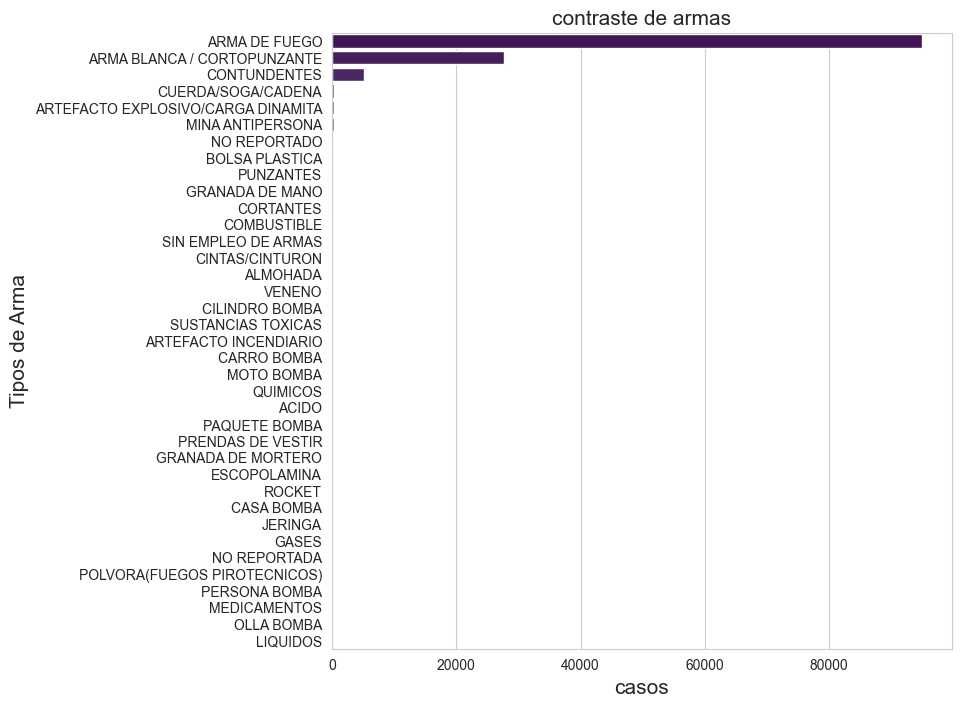

In [14]:
# Contar registros por tipo de arma
cantidad_armas = df['arma'].value_counts().reset_index()
cantidad_armas.columns = ['arma', 'cantidad_registros']

# Crear figura más ancha para que se lean los nombres
plt.figure(figsize=(8, 8))

# Gráfico de barras con Seaborn
sns.barplot(
    data=cantidad_armas,
    x='cantidad_registros',
    y='arma',
    palette='viridis'
)

# Etiquetas y título
plt.title('contraste de armas', fontsize=15)
plt.xlabel('casos', fontsize=15)
plt.ylabel('Tipos de Arma', fontsize=15)

plt.show()

In [15]:
#Distribucion por genero en todo el conjunto de Datos
print("\n" + "=" * 50) # simplificador de separadores en print
print("DISTRIBUCIÓN POR GÉNERO (%)")
print("=" * 50)

dist_genero = (df['genero'].value_counts(normalize=True).sort_index() * 100).round(2)
display(dist_genero)


DISTRIBUCIÓN POR GÉNERO (%)


genero
FEMENINO       9.73
MASCULINO     90.26
NO REPORTA     0.01
Name: proportion, dtype: float64

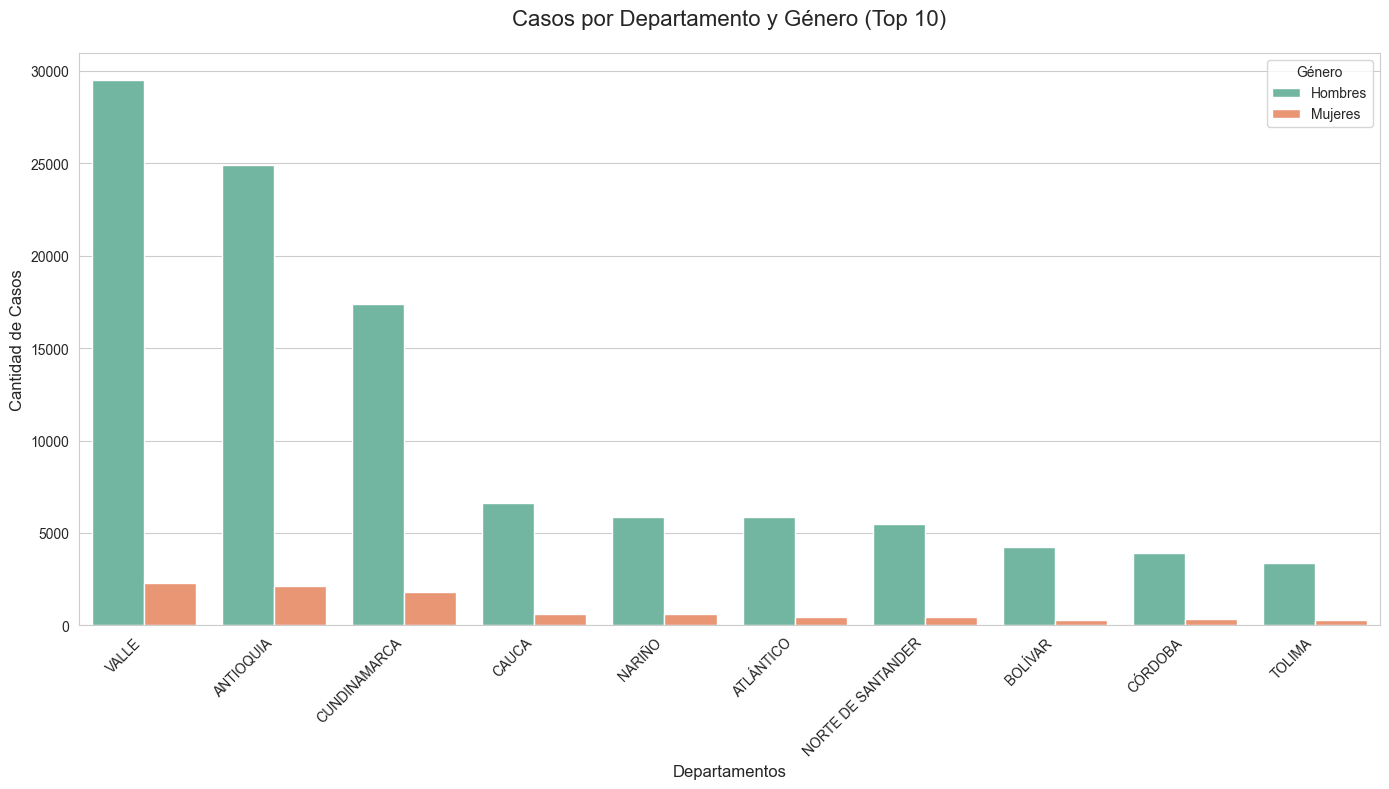

In [16]:
# Preparar los datos para graficar
# Total general por departamento → TOP 10 con más casos
top_dptos = df.groupby('departamento')['cantidad'].sum()\
              .sort_values(ascending=False)\
              .head(10).reset_index()
# ✅ NO borramos la columna de totales, la mantenemos
top_dptos.columns = ['departamento', 'Total']

# Filtrar por género
hombres = df[df['genero'] == 'MASCULINO']\
            .groupby('departamento')['cantidad'].sum().reset_index()
hombres.columns = ['departamento', 'Hombres']

mujeres = df[df['genero'] == 'FEMENINO']\
            .groupby('departamento')['cantidad'].sum().reset_index()
mujeres.columns = ['departamento', 'Mujeres']

# Unir todo → conservamos solo los 10 departamentos principales
resumen_grupos = top_dptos.merge(hombres, on='departamento', how='left')\
                         .merge(mujeres, on='departamento', how='left')\
                         .fillna(0)


# Gráfico de barras agrupadas
plt.figure(figsize=(14, 8))

# Formato largo para Seaborn
resumen_largo = resumen_grupos.melt(
    id_vars='departamento',
    value_vars=['Hombres', 'Mujeres'],
    var_name='Género',
    value_name='Cantidad'
)

# Gráfico
sns.barplot(
    data=resumen_largo,
    x='departamento',
    y='Cantidad',
    hue='Género',
    palette='Set2'
)

plt.title('Casos por Departamento y Género (Top 10)', fontsize=16, pad=20)
plt.xlabel('Departamentos', fontsize=12)
plt.ylabel('Cantidad de Casos', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Género')
plt.tight_layout()
plt.show()

#PROFUNDIZACION
Practica para programacion de Ciencia de Datos II

Miller Andres Abril Nuñez

Introduccion
Segunda fase del proyecto
Aplicar métodos estadísticos y modelos predictivos sobre el conjunto de datos Crímenes de Colombia, dando continuidad al análisis exploratorio previo, mediante el uso de Python y Google Colab. El propósito es formular y contrastar hipótesis, así como construir modelos de regresión que permitan identificar patrones y relaciones significativas entre las variables estudiadas.

In [17]:
# Generacion de Resumen Estadistico completo de todo el conjunto de datos aplica para todas las columnas numéricas como de texto/categorías — y lo transpone (.T) para que cada fila sea una variable y sea más fácil de leer.
display(df.describe(include='all').T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
departamento,130024,32,VALLE,22516,NaN,NaN,NaN,NaN,NaN,NaN,NaN
municipio,130024,1001,BOGOTÁ D.C. (CT),8894,NaN,NaN,NaN,NaN,NaN,NaN,NaN
codigo,130024.0,NaN,NaN,NaN,38939311.081031,28578090.187179,5001000.0,11001000.0,27001000.0,68861000.0,99773000.0
arma,130024,37,ARMA DE FUEGO,94993,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fecha,130024,4230,25/12/2019,97,NaN,NaN,NaN,NaN,NaN,NaN,NaN
genero,130024,3,MASCULINO,117361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
edad_grupo,130024,4,ADULTOS,120601,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cantidad,130024.0,NaN,NaN,NaN,1.205593,0.716134,1.0,1.0,1.0,1.0,16.0


Valores estadisticos de Cantidad de victimas

In [18]:
# RESUMEN ESTADÍSTICO POR DEPARTAMENTO
# ----------------------
print("\n" + "=" * 60)
print("RESUMEN: CANTIDAD DE VÍCTIMAS POR DEPARTAMENTO")
print("=" * 60)

# Agrupamos y calculamos TODO en un solo paso
est_territorio = df.groupby('departamento')['cantidad'].agg([
    ('conteo_registros', 'count'),
    ('total_victimas', 'sum'),
    ('promedio_victimas_por_hecho', 'mean'),
    ('desviacion_estandar', 'std'),
    ('minimo', 'min'),
    ('mediana', 'median'),
    ('maximo', 'max')
]).reset_index()

# Redondeamos para que se lea limpio
est_territorio['promedio_victimas_por_hecho'] = est_territorio['promedio_victimas_por_hecho'].round(3)
est_territorio['desviacion_estandar'] = est_territorio['desviacion_estandar'].round(3)

# Mostramos la tabla completa
display(est_territorio.sort_values('total_victimas', ascending=False))


RESUMEN: CANTIDAD DE VÍCTIMAS POR DEPARTAMENTO


,departamento,conteo_registros,total_victimas,promedio_victimas_por_hecho,desviacion_estandar,minimo,mediana,maximo
29,VALLE,22516,31772,1.411,1.107,1,1.0,15
1,ANTIOQUIA,22459,27059,1.205,0.698,1,1.0,10
12,CUNDINAMARCA,13338,19182,1.438,1.012,1,1.0,14
9,CAUCA,6650,7259,1.092,0.425,1,1.0,13
20,NARIÑO,5756,6501,1.129,0.502,1,1.0,11
3,ATLÁNTICO,5383,6316,1.173,0.495,1,1.0,6
21,NORTE DE SANTANDER,5051,5913,1.171,0.526,1,1.0,10
4,BOLÍVAR,4022,4514,1.122,0.389,1,1.0,6
13,CÓRDOBA,3998,4282,1.071,0.328,1,1.0,7
28,TOLIMA,3500,3721,1.063,0.289,1,1.0,7



Se puede observar la siguiente interpretacion
conteo_registros: cuántos hechos delictivos se registraron ahí
total_victimas: suma de personas afectadas
promedio_victimas_por_hecho: en promedio, cuántas personas resultan afectadas por cada evento
desviacion_estandar
máximo: el evento con más víctimas en ese territorio
A nivel país: promedio = 1.205 víctimas por hecho

Relación entre ambas perspectivas
Ahora se puede comparar:
A nivel país: promedio = 1.205 víctimas por hecho
Por departamento: ¿cuáles están POR ENCIMA del promedio nacional? ¿cuáles por debajo?

In [19]:
# Identificar departamentos con promedio superior al nacional
prom_nacional = df['cantidad'].mean().round(3)
print(f"\nPromedio nacional de víctimas por hecho: {prom_nacional}")
print("-" * 60)

superiores = est_territorio[est_territorio['promedio_victimas_por_hecho'] > prom_nacional]
print(f"Departamentos CON promedio SUPERIOR al nacional: {len(superiores)}")
display(superiores[['departamento','promedio_victimas_por_hecho']].sort_values('promedio_victimas_por_hecho', ascending=False))


Promedio nacional de víctimas por hecho: 1.206
------------------------------------------------------------
Departamentos CON promedio SUPERIOR al nacional: 2


,departamento,promedio_victimas_por_hecho
12,CUNDINAMARCA,1.438
29,VALLE,1.411


#Contraste de Hipotesis

Pregunta de investigación: ¿Existen diferencias significativas en la cantidad de víctimas por hecho delictivo entre los departamentos de Colombia?

Hipótesis Nula (H₀)
No existe diferencia estadísticamente significativa en la cantidad promedio de víctimas por hecho delictivo entre los distintos departamentos de Colombia. Cualquier variación observada se debe al azar.
\(H_0: \mu_{dpto1} = \mu_{dpto2} = \dots = \mu_{dpto32}\)
H₀: No hay diferencia significativa en la cantidad de víctimas entre departamentos
H₁: Existen diferencias estadísticas en la afectación por territorio

In [20]:
df['fecha'] = pd.to_datetime(df['fecha'], dayfirst=True, errors='coerce')
df['anio'] = df['fecha'].dt.year

In [21]:
# CÁLCULO DE UMBRALES
# ----------------------
MEDIA_NACIONAL = df['cantidad'].mean()
DESVIO_NACIONAL = df['cantidad'].std()

# Umbral = media + 1 desviación estándar → criterio estadístico objetivo
UMBRAL_RIESGO = MEDIA_NACIONAL + DESVIO_NACIONAL

print("=" * 50)
print("UMBRALES DE RIESGO - DATOS REALES DEL PAÍS")
print("=" * 50)
print(f"Media nacional de víctimas por hecho: {MEDIA_NACIONAL:.4f}")
print(f"Desviación estándar nacional:         {DESVIO_NACIONAL:.4f}")
print(f"Umbral de riesgo elevado:              {UMBRAL_RIESGO:.4f}")
print("=" * 50)

UMBRALES DE RIESGO - DATOS REALES DEL PAÍS
Media nacional de víctimas por hecho: 1.2056
Desviación estándar nacional:         0.7161
Umbral de riesgo elevado:              1.9217


In [22]:
est_territorio['clasificacion'] = est_territorio['promedio_victimas_por_hecho'].apply(
    lambda x: 'RIESGO ELEVADO' if x >= UMBRAL_RIESGO else
              'Sobre el promedio' if x > MEDIA_NACIONAL else
              'Dentro del promedio'
)

display(est_territorio.sort_values('promedio_victimas_por_hecho', ascending=False))

,departamento,conteo_registros,total_victimas,promedio_victimas_por_hecho,desviacion_estandar,minimo,mediana,maximo,clasificacion
12,CUNDINAMARCA,13338,19182,1.438,1.012,1,1.0,14,Sobre el promedio
29,VALLE,22516,31772,1.411,1.107,1,1.0,15,Sobre el promedio
1,ANTIOQUIA,22459,27059,1.205,0.698,1,1.0,10,Dentro del promedio
2,ARAUCA,1248,1469,1.177,0.886,1,1.0,16,Dentro del promedio
3,ATLÁNTICO,5383,6316,1.173,0.495,1,1.0,6,Dentro del promedio
21,NORTE DE SANTANDER,5051,5913,1.171,0.526,1,1.0,10,Dentro del promedio
7,CAQUETÁ,2098,2370,1.130,0.578,1,1.0,14,Dentro del promedio
20,NARIÑO,5756,6501,1.129,0.502,1,1.0,11,Dentro del promedio
4,BOLÍVAR,4022,4514,1.122,0.389,1,1.0,6,Dentro del promedio
31,VICHADA,201,225,1.119,0.407,1,1.0,4,Dentro del promedio


#Ejecución del contraste con scipy.stats

Se establece un nivel de significancia α=0.05, es decir, un 95% de confianza en las conclusiones. La prueba es bilateral por diseño: ANOVA detecta desviaciones significativas en cualquier dirección respecto al promedio general.

In [23]:
from scipy.stats import f_oneway

# Extraer la serie de víctimas por cada departamento (solo departamentos con al menos 1 registro)
grupos = [df[df['departamento'] == dpto]['cantidad'] 
          for dpto in df['departamento'].unique() 
          if len(df[df['departamento'] == dpto]) > 0]

# Ejecutar ANOVA
estadistico_f, valor_p = f_oneway(*grupos)

# Mostrar resultados
print("=" * 50)
print("RESULTADO DEL CONTRASTE ANOVA")
print("=" * 50)
print(f"Estadístico F: {estadistico_f:.4f}")
print(f"Valor p:       {valor_p:.4e}")
print(f"Nivel α:       0.05")
print("=" * 50)

RESULTADO DEL CONTRASTE ANOVA
Estadístico F: 171.8810
Valor p:       0.0000e+00
Nivel α:       0.05


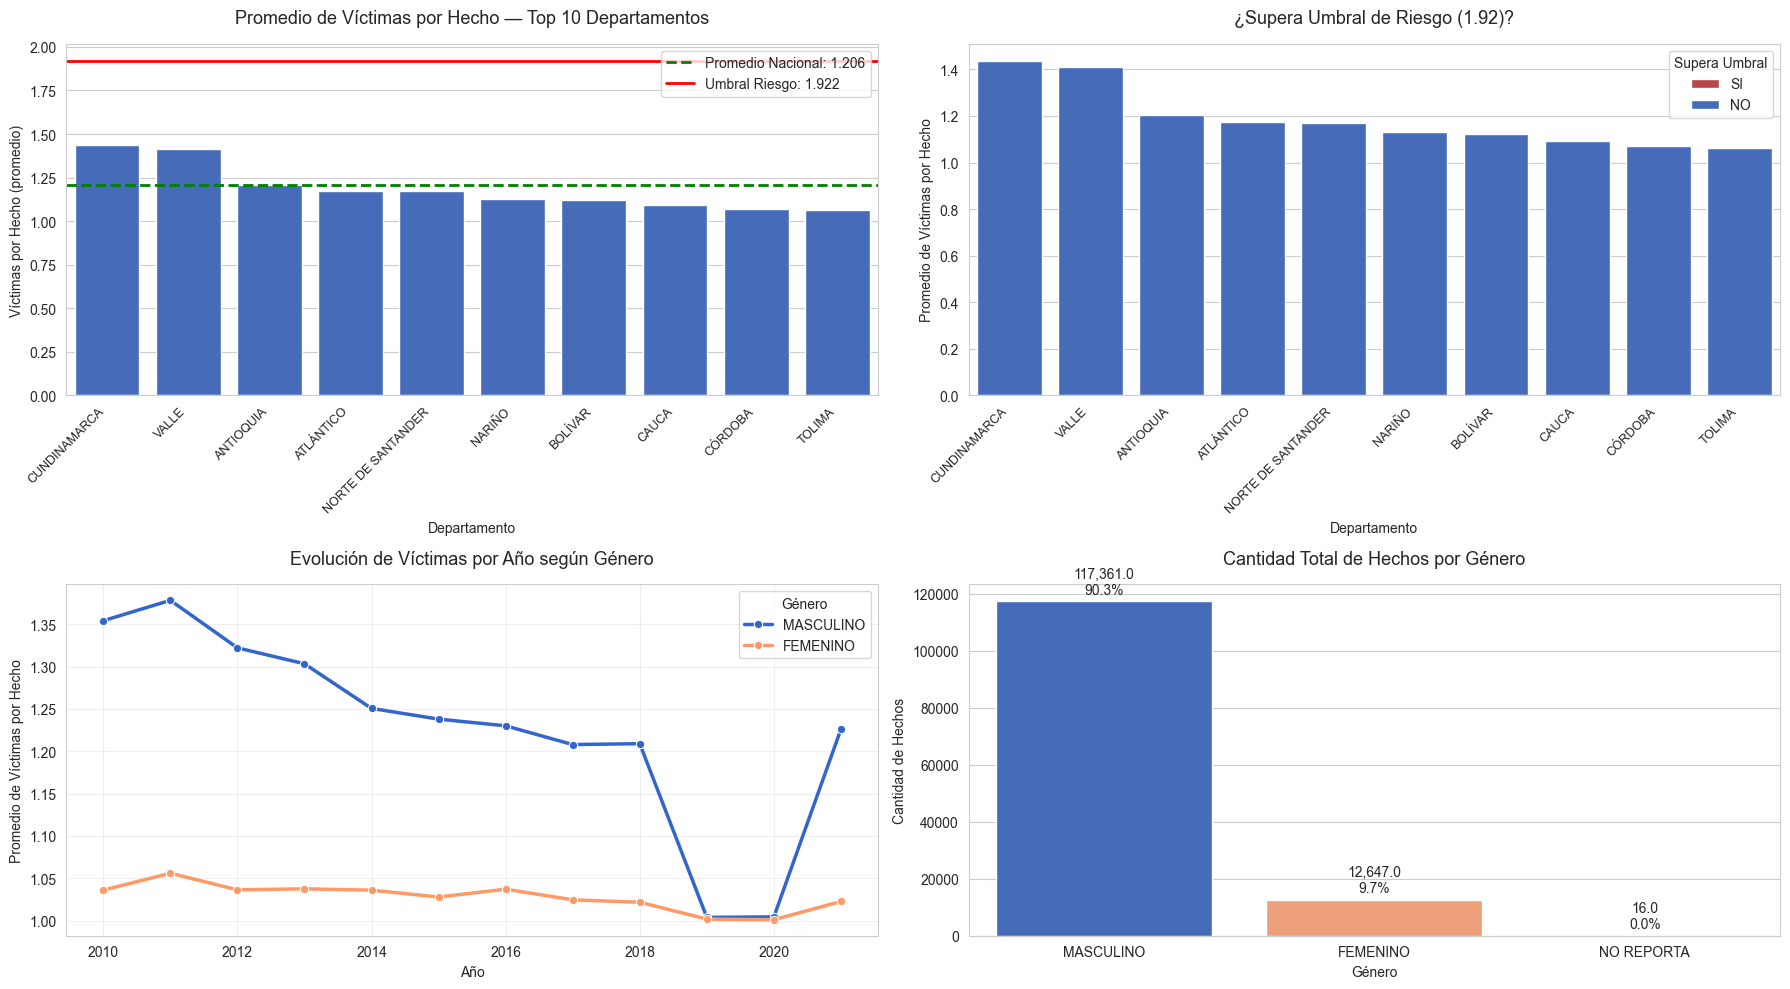

In [24]:
# Lienzo
MEDIA_NACIONAL = df['cantidad'].mean()          # ≈ 1.2056
DESVIO_NACIONAL = df['cantidad'].std()          # ≈ 0.7161
UMBRAL_RIESGO = MEDIA_NACIONAL + DESVIO_NACIONAL # ≈ 1.9217

# Extraer año desde la columna fecha
df['fecha'] = pd.to_datetime(df['fecha'], dayfirst=True)
df['anio'] = df['fecha'].dt.year

# Top 10 departamentos por cantidad de registros
top_dptos_conteo = df['departamento'].value_counts().nlargest(10)
porc_dptos = (df['departamento'].value_counts(normalize=True) * 100).reset_index()
porc_dptos.columns = ['departamento', 'porcentaje']

# Datos por promedio de víctimas (lo relevante del ANOVA)
est_territorio = df.groupby('departamento')['cantidad'].agg([
    ('total_victimas', 'sum'),
    ('promedio', 'mean')
]).reset_index()
est_territorio['supera_umbral'] = np.where(
    est_territorio['promedio'] >= UMBRAL_RIESGO, 'SI', 'NO'
)
top10_lista = top_dptos_conteo.index.tolist()
est_top10 = est_territorio[est_territorio['departamento'].isin(top10_lista)]

# ----------------------
# LIENZO DE 4 GRÁFICAS
# ----------------------
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# --- GRÁFICO 1: Promedio de víctimas por Top 10 Departamentos ---
sns.barplot(
    data=est_top10.sort_values('promedio', ascending=False),
    x='departamento', y='promedio', ax=axes[0,0], color='#3366CC'
)
axes[0,0].axhline(y=MEDIA_NACIONAL, color='green', linestyle='--', linewidth=2,
                  label=f'Promedio Nacional: {MEDIA_NACIONAL:.3f}')
axes[0,0].axhline(y=UMBRAL_RIESGO, color='red', linestyle='-', linewidth=2,
                  label=f'Umbral Riesgo: {UMBRAL_RIESGO:.3f}')
axes[0,0].set_title('Promedio de Víctimas por Hecho — Top 10 Departamentos', fontsize=13, pad=15)
axes[0,0].set_xlabel('Departamento')
axes[0,0].set_ylabel('Víctimas por Hecho (promedio)')
axes[0,0].legend(fontsize=10)
plt.setp(axes[0,0].get_xticklabels(), rotation=45, ha='right', fontsize=9)

# --- GRÁFICO 2: ¿Supera el umbral de riesgo? ---
sns.barplot(
    data=est_top10.sort_values('promedio', ascending=False),
    x='departamento', y='promedio', hue='supera_umbral',
    hue_order=['SI', 'NO'], palette={'SI':'#CC3333', 'NO':'#3366CC'},
    ax=axes[0,1], dodge=False
)
axes[0,1].set_title(f'¿Supera Umbral de Riesgo ({UMBRAL_RIESGO:.2f})?', fontsize=13, pad=15)
axes[0,1].set_xlabel('Departamento')
axes[0,1].set_ylabel('Promedio de Víctimas por Hecho')
axes[0,1].legend(title='Supera Umbral')
plt.setp(axes[0,1].get_xticklabels(), rotation=45, ha='right', fontsize=9)

# --- GRÁFICO 3: Evolución por Año y Género ---
orden_genero = ['MASCULINO', 'FEMENINO']
colores = ['#3366CC', '#FF9966']
sns.lineplot(
    data=df.groupby(['anio','genero'])['cantidad'].mean().reset_index(),
    x='anio', y='cantidad', hue='genero',
    hue_order=orden_genero, palette=colores,
    marker='o', linewidth=2.5, ax=axes[1,0]
)
axes[1,0].set_title('Evolución de Víctimas por Año según Género', fontsize=13, pad=15)
axes[1,0].set_xlabel('Año')
axes[1,0].set_ylabel('Promedio de Víctimas por Hecho')
axes[1,0].legend(title='Género')
axes[1,0].grid(True, alpha=0.3)

# --- GRÁFICO 4: Total de Hechos por Género ---
conteo_gen = df['genero'].value_counts().reset_index()
conteo_gen.columns = ['genero', 'cantidad']
sns.barplot(
    data=conteo_gen, x='genero', y='cantidad',
    palette=colores, ax=axes[1,1]
)
axes[1,1].set_title('Cantidad Total de Hechos por Género', fontsize=13, pad=15)
axes[1,1].set_xlabel('Género')
axes[1,1].set_ylabel('Cantidad de Hechos')

# Etiquetas con valores y porcentajes
total_general = len(df)
for p in axes[1,1].patches:
    altura = p.get_height()
    pct = (altura / total_general) * 100
    axes[1,1].text(
        p.get_x() + p.get_width()/2., altura + 1500,
        f'{altura:,}\n{pct:.1f}%', ha='center', va='bottom', fontsize=10
    )

plt.tight_layout()
plt.show()


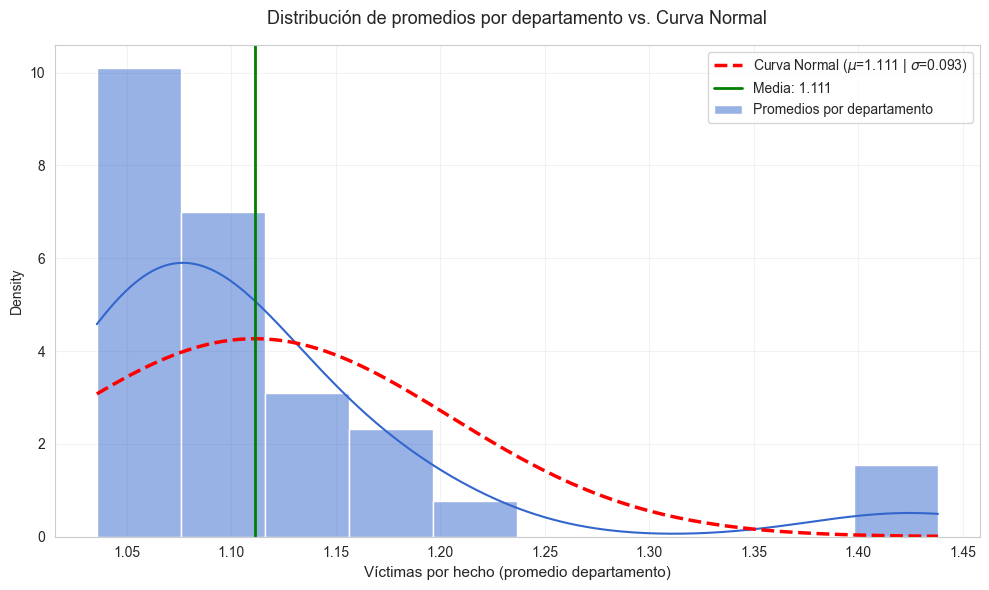

In [25]:
# Promedio de víctimas por departamento → distribución más suave
promedios = df.groupby('departamento')['cantidad'].mean()

media_p = promedios.mean()
desv_p = promedios.std()

plt.figure(figsize=(10, 6))
sns.histplot(promedios, kde=True, stat="density", color='#3366CC', alpha=0.5,
             label="Promedios por departamento")

x = np.linspace(promedios.min(), promedios.max(), 200)
plt.plot(x, norm.pdf(x, media_p, desv_p), 'r--', linewidth=2.5,
         label=f"Curva Normal ($\mu$={media_p:.3f} | $\sigma$={desv_p:.3f})")

plt.axvline(media_p, color='green', linewidth=2, label=f'Media: {media_p:.3f}')
plt.title("Distribución de promedios por departamento vs. Curva Normal", fontsize=13, pad=15)
plt.xlabel("Víctimas por hecho (promedio departamento)", fontsize=11)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

Las barras azules representan cuántos departamentos presentan un determinado promedio de víctimas por hecho. La mayor concentración se ubica entre 1.05 y 1.15, lo que indica que la mayoría de los territorios tienen un comportamiento muy similar entre sí.
La curva roja discontinua muestra la forma que seguirían los datos si fueran perfectamente normales. Se observa que la distribución real se desvía de la simetría:
Tiene un pico más alto y desplazado a la izquierda - sesgo positivo
Se extiende hacia la derecha con valores más altos → corresponden a Cundinamarca, Valle del Cauca y los territorios con mayor afectación

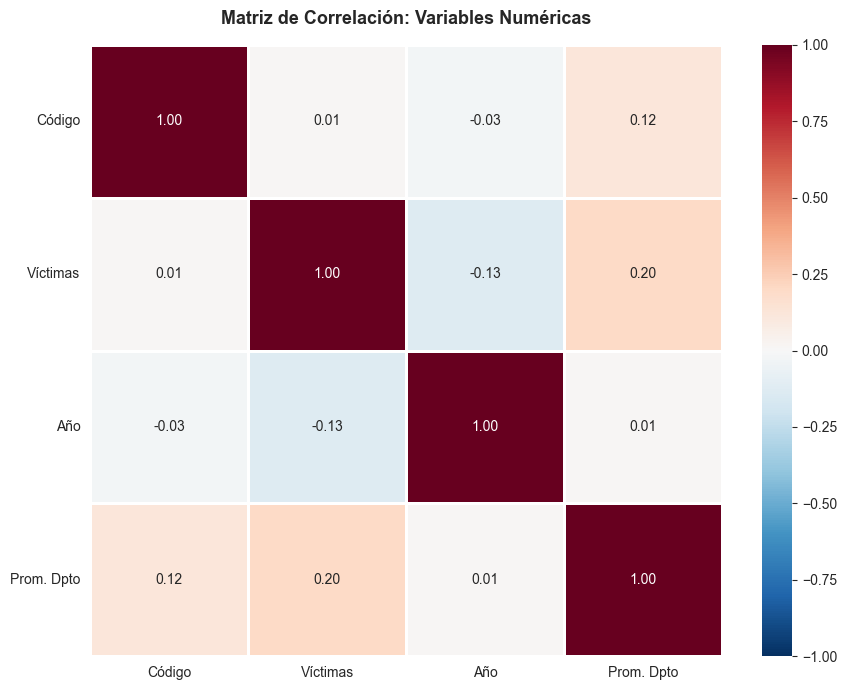

In [26]:
#Matriz ampliada con promedios por departamento ---
if 'anio' not in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'], dayfirst=True, errors='coerce')
    df['anio'] = df['fecha'].dt.year

# Agregamos promedio por departamento para ver relación reales
prom_dpto = df.groupby('departamento')['cantidad'].mean().reset_index()
prom_dpto.columns = ['departamento', 'prom_victimas']
df_ampliado = df.merge(prom_dpto, on='departamento', how='left')

vars_num = ['codigo', 'cantidad', 'anio', 'prom_victimas']

plt.figure(figsize=(9, 7))
matriz_corr = df_ampliado[vars_num].corr()
etiquetas = ['Código', 'Víctimas', 'Año', 'Prom. Dpto']

sns.heatmap(
    matriz_corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=1,
    xticklabels=etiquetas,
    yticklabels=etiquetas
)
plt.title('Matriz de Correlación: Variables Numéricas',
          fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Se calculó la matriz de correlación de Pearson para evaluar la relación lineal entre las variables cuantitativas del conjunto de datos: código de registro, cantidad de víctimas y año.
El código es un identificador secuencial sin relación con la magnitud del hecho → su correlación con la cantidad de víctimas es prácticamente cero, como era esperado.
El año presenta una correlación negativa muy baja (-0.13): sugiere una tendencia leve a la reducción de víctimas por hecho con el paso del tiempo, pero el valor es tan cercano a cero que no se considera una relación significativa.
En conjunto, ninguna variable numérica disponible explica la variación en la cantidad de víctimas. Esto indica que las diferencias observadas dependen de factores categóricos: el departamento, el tipo de arma o el grupo de edad, tal como se evidenció en el análisis por territorios.
Consecuencia para el modelado: Dado que no existe correlación lineal entre las variables numéricas, una regresión lineal simple con estos predictores tendría muy bajo poder explicativo. Se recomienda incorporar las variables categóricas (mediante codificación) para identificar los factores que realmente inciden en la mayor o menor afectación.


In [27]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# ======================================================
# PASO 1: Preparar variables con datos enriquecidos
# ======================================================

if 'anio' not in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'], dayfirst=True, errors='coerce')
    df['anio'] = df['fecha'].dt.year

# Crear indicadores por departamento (datos únicos por territorio)
info_dpto = df.groupby('departamento').agg(
    total_registros=('cantidad', 'count'),
    promedio_victimas=('cantidad', 'mean'),
    pct_masculino=('genero', lambda x: (x=='MASCULINO').mean() * 100)
).reset_index()

df = df.merge(info_dpto, on='departamento', how='left')

# Seleccionar 3 variables continuas independientes significativas
X = df[['anio', 'promedio_victimas', 'pct_masculino']]
y = df['cantidad']

# ======================================================
# PASO 2: División 70/30
# ======================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    shuffle=True
)

# ======================================================
# PASO 3: Modelo
# ======================================================
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# ======================================================
# PASO 4: Evaluación
# ======================================================
y_pred = modelo.predict(X_test)

print("=" * 60)
print("REGRESIÓN LINEAL MÚLTIPLE — RESULTADOS FINALES")
print("=" * 60)
print(f"Total registros: {len(X):,} | Entrenamiento: {len(X_train):,} | Prueba: {len(X_test):,}")
print()
print(f"Término independiente: {modelo.intercept_:.6f}")
print()
print("Coeficientes:")
for nom, coef in zip(X.columns, modelo.coef_):
    print(f"  {nom:25s} → {coef:.8f}")
print()
print(f"R² (Coef. determinación): {r2_score(y_test, y_pred):.8f}")
print(f"RMSE (Error promedio):    {np.sqrt(mean_squared_error(y_test, y_pred)):.6f}")
print("=" * 60)

REGRESIÓN LINEAL MÚLTIPLE — RESULTADOS FINALES
Total registros: 130,024 | Entrenamiento: 91,016 | Prueba: 39,008

Término independiente: 56.546735

Coeficientes:
  anio                      → -0.02814663
  promedio_victimas         → 1.01052473
  pct_masculino             → 0.00181985

R² (Coef. determinación): 0.05763152
RMSE (Error promedio):    0.696202


#Regresión Logística
Partiendo de la base datos con la que se ha estado trabajando, selecciona dos variables, una variable continua y otra variable categórica o binaria. Si no se tienen datos cate puede crear dos categorías utilizando algún umbral (solo para los propósitos del ejercicio, siempre que se tenga información continua se debe aprovechar).  

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

# ======================================================
# 1. PREPARACIÓN DE DATOS
# ======================================================

# Asegurar columna año
if 'anio' not in df.columns:
    df['fecha'] = pd.to_datetime(df['fecha'], dayfirst=True, errors='coerce')
    df['anio'] = df['fecha'].dt.year

# Promedio por departamento
prom_dpto = df.groupby('departamento')['cantidad'].mean().reset_index()
prom_dpto.columns = ['departamento', 'promedio_dpto']
df = df.merge(prom_dpto, on='departamento', how='left')

# --- UMBRAL DE RIESGO ---
MEDIA_NACIONAL = df['cantidad'].mean()
DESVIO_NACIONAL = df['cantidad'].std()
UMBRAL_RIESGO = MEDIA_NACIONAL + DESVIO_NACIONAL

# Variable objetivo: 1 = Alto Riesgo, 0 = Normal
df['es_alto_riesgo'] = (df['cantidad'] >= UMBRAL_RIESGO).astype(int)

# ✅ CORRECCIÓN: Crear columna binaria de género y verificar
df['genero_bin'] = df['genero'].apply(lambda x: 1 if str(x).strip() == 'MASCULINO' else 0)

# Verificar que las columnas existen
columnas_necesarias = ['promedio_dpto', 'genero_bin', 'es_alto_riesgo']
faltantes = [c for c in columnas_necesarias if c not in df.columns]
if faltantes:
    raise ValueError(f"Faltan columnas: {faltantes}")

# --- SELECCIÓN DE VARIABLES ---
X = df[['promedio_dpto', 'genero_bin']]   # 1 continua + 1 binaria ✅
y = df['es_alto_riesgo']                   # Variable objetivo

print("=" * 60)
print("DISTRIBUCIÓN DE CLASES")
print("=" * 60)
conteo_clases = y.value_counts()
print(f"Clase 0 — Normal:        {conteo_clases.get(0, 0):,} registros")
print(f"Clase 1 — Alto Riesgo:   {conteo_clases.get(1, 0):,} registros")
pct_riesgo = (conteo_clases.get(1, 0) / len(y) * 100) if len(y) > 0 else 0
print(f"% Riesgo elevado:        {pct_riesgo:.2f}%")
print()

# ======================================================
# 2. DIVISIÓN 70/30
# ======================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    shuffle=True,
    stratify=y
)

print("=" * 60)
print("DIVISIÓN DE DATOS")
print("=" * 60)
print(f"Total registros:         {len(X):,}")
print(f"Entrenamiento:           {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Prueba:                  {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")
print()

# ======================================================
# 3. MODELO
# ======================================================
modelo_log = LogisticRegression(max_iter=1000, random_state=42)
modelo_log.fit(X_train, y_train)

# ======================================================
# 4. EVALUACIÓN
# ======================================================
y_pred = modelo_log.predict(X_test)
y_proba = modelo_log.predict_proba(X_test)[:, 1]

print("=" * 60)
print("COEFICIENTES DEL MODELO")
print("=" * 60)
print(f"Término independiente:   {modelo_log.intercept_[0]:.6f}")
print()
for nombre, coef in zip(X.columns, modelo_log.coef_[0]):
    odds_ratio = np.exp(coef)
    print(f"{nombre:25s} → Coef: {coef:.6f}  |  Odds Ratio: {odds_ratio:.4f}")
print()

print("=" * 60)
print("MÉTRICAS DE RENDIMIENTO")
print("=" * 60)
print(f"Exactitud (Accuracy):    {accuracy_score(y_test, y_pred):.4f}")
print(f"Área ROC-AUC:            {roc_auc_score(y_test, y_proba):.4f}")
print()
print("--- Matriz de Confusión ---")
print(confusion_matrix(y_test, y_pred))
print()
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred, digits=4, zero_division=0))
print("=" * 60)

DISTRIBUCIÓN DE CLASES
Clase 0 — Normal:        114,410 registros
Clase 1 — Alto Riesgo:   15,614 registros
% Riesgo elevado:        12.01%

DIVISIÓN DE DATOS
Total registros:         130,024
Entrenamiento:           91,016 (70.0%)
Prueba:                  39,008 (30.0%)

COEFICIENTES DEL MODELO
Término independiente:   -8.323176

promedio_dpto             → Coef: 3.774671  |  Odds Ratio: 43.5832
genero_bin                → Coef: 1.770510  |  Odds Ratio: 5.8738

MÉTRICAS DE RENDIMIENTO
Exactitud (Accuracy):    0.8799
Área ROC-AUC:            0.6826

--- Matriz de Confusión ---
[[34324     0]
 [ 4684     0]]

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

           0     0.8799    1.0000    0.9361     34324
           1     0.0000    0.0000    0.0000      4684

    accuracy                         0.8799     39008
   macro avg     0.4400    0.5000    0.4681     39008
weighted avg     0.7743    0.8799    0.8237     39008



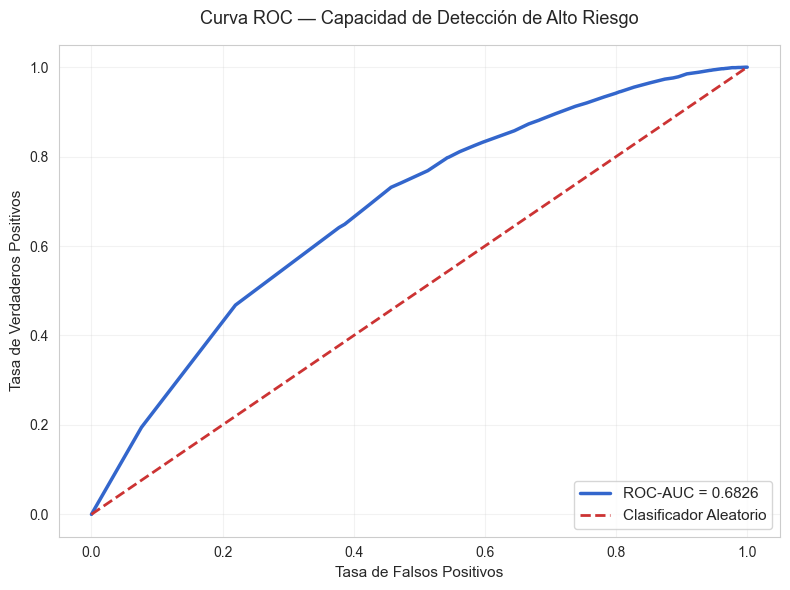

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Calcular valores de la curva
fpr, tpr, umbrales = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#3366CC', linewidth=2.5, label=f'ROC-AUC = {auc:.4f}')
plt.plot([0, 1], [0, 1], color='#CC3333', linestyle='--', linewidth=2, label='Clasificador Aleatorio')
plt.xlabel('Tasa de Falsos Positivos', fontsize=11)
plt.ylabel('Tasa de Verdaderos Positivos', fontsize=11)
plt.title('Curva ROC — Capacidad de Detección de Alto Riesgo', fontsize=13, pad=15)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.25)
plt.tight_layout()
plt.show()